In [1]:
import os
print(os.getcwd())

c:\Users\ayush ranjan\AppData\Local\Programs\Microsoft VS Code


In [2]:
import pandas as pd
from sqlalchemy import create_engine

server = "LAPTOP-GFQ808Q2"
database = "inventory"
driver = "ODBC Driver 17 for SQL Server"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}"
)

query = """
SELECT TABLE_NAME 
FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_TYPE = 'BASE TABLE'
"""

tables = pd.read_sql(query, engine)
tables

,TABLE_NAME
0,sales
1,vendor_invoice
2,begin_inventory
3,end_inventory
4,purchases
5,purchase_prices


In [3]:
for table in tables['TABLE_NAME']:
    print('-'*50, f'{table}','-'*50)
    print('Count of records:',pd.read_sql(f"select count(*) as count from {table}",engine)['count'].values[0])
    display(pd.read_sql(f"select top 5 * from {table}",engine))

-------------------------------------------------- sales --------------------------------------------------
Count of records: 12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,69_MOUNTMEND_45392,69,45392,Norton RSV Malbec Mendoza,750mL,1,18.99,18.99,2024-11-25,750.0,2,0.11,4425,MARTIGNETTI COMPANIES
1,69_MOUNTMEND_4540,69,4540,Chase Elderflower Liqueur,750mL,1,24.99,24.99,2024-11-04,750.0,1,0.79,6785,PALM BAY INTERNATIONAL INC
2,69_MOUNTMEND_45424,69,45424,Gruet Blanc de Noir,750mL,1,16.99,16.99,2024-11-10,750.0,2,0.11,17033,SEA BREEZE CELLARS LLC
3,69_MOUNTMEND_45424,69,45424,Gruet Blanc de Noir,750mL,3,50.97,16.99,2024-11-18,750.0,2,0.34,17033,SEA BREEZE CELLARS LLC
4,69_MOUNTMEND_45457,69,45457,R Mondavi Meritage Pvt Slctn,750mL,1,10.99,10.99,2024-11-19,750.0,2,0.11,1392,CONSTELLATION BRANDS INC


-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of records: 5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


-------------------------------------------------- begin_inventory --------------------------------------------------
Count of records: 206529


...

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,70_KELD_6349,70,KELD,6349,Glen Ellen Chard RSV,1.5L,35,6.99,2024-12-31
1,70_KELD_6351,70,KELD,6351,Kendall Jackson Vntr RSV Cab,750mL,18,16.99,2024-12-31
2,70_KELD_6356,70,KELD,6356,Taylor Cream Sherry,1.5L,14,7.79,2024-12-31
3,70_KELD_6358,70,KELD,6358,Dom Ste Michelle Brut Cuvee,750mL,5,12.99,2024-12-31
4,70_KELD_6360,70,KELD,6360,Taylor Nys Cream Sherry,3L,6,13.99,2024-12-31


-------------------------------------------------- purchases --------------------------------------------------
Count of records: 2372474


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,39_EASTHALLOW_8023,39,8023,DeKuyper Triple Sec,750mL,12546,JIM BEAM BRANDS COMPANY,12469,2024-10-05,2024-10-13,2024-10-21,2024-11-28,3.28,12,39.36,1
1,48_NORFOLK_3696,48,3696,Gilbeys Vodka,1.75L,12546,JIM BEAM BRANDS COMPANY,12469,2024-10-05,2024-10-10,2024-10-21,2024-11-28,7.60,6,45.60,1
2,34_PITMERDEN_3221,34,3221,Pinnacle Raspberry Vodka,750mL,12546,JIM BEAM BRANDS COMPANY,12469,2024-10-05,2024-10-12,2024-10-21,2024-11-28,7.93,12,95.16,1
3,21_BALERNO_1395,21,1395,Old Crow,750mL,12546,JIM BEAM BRANDS COMPANY,12469,2024-10-05,2024-10-11,2024-10-21,2024-11-28,5.88,11,64.68,1
4,13_TARMSWORTH_1376,13,1376,Jim Beam,1.75L,12546,JIM BEAM BRANDS COMPANY,12469,2024-10-05,2024-10-12,2024-10-21,2024-11-28,16.29,76,1238.04,1


-------------------------------------------------- purchase_prices --------------------------------------------------
Count of records: 12261


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


In [4]:
purchases = pd.read_sql("select * from purchases where VendorNumber = 4466",engine)
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,32_MOUNTMEND_3140,32,3140,TGI Fridays Orange Dream,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12552,2024-10-11,2024-10-17,2024-10-24,2024-11-30,11.19,6,67.14,1
1,35_HALIVAARA_5255,35,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12552,2024-10-11,2024-10-20,2024-10-24,2024-11-30,9.35,6,56.10,1
2,25_CAERSHIRE_5255,25,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12552,2024-10-11,2024-10-18,2024-10-24,2024-11-30,9.35,6,56.10,1
3,66_EANVERNESS_3140,66,3140,TGI Fridays Orange Dream,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12552,2024-10-11,2024-10-18,2024-10-24,2024-11-30,11.19,6,67.14,1
4,70_KELD_5255,70,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12552,2024-10-11,2024-10-21,2024-10-24,2024-11-30,9.35,6,56.10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,73_DONCASTER_5255,73,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12413,2024-10-02,2024-10-12,2024-10-24,2024-11-29,9.35,6,56.10,1
2188,31_HORNSEY_5255,31,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12413,2024-10-02,2024-10-13,2024-10-24,2024-11-29,9.35,6,56.10,1
2189,7_STANMORE_3140,7,3140,TGI Fridays Orange Dream,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12413,2024-10-02,2024-10-11,2024-10-24,2024-11-29,11.19,6,67.14,1
2190,67_EANVERNESS_5255,67,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,12413,2024-10-02,2024-10-14,2024-10-24,2024-11-29,9.35,5,46.75,1


In [5]:
purchase_prices = pd.read_sql("select * from purchase_prices where VendorNumber = 4466",engine)
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [6]:
vendor_invoice = pd.read_sql("select * from vendor_invoice where VendorNumber = 4466",engine)
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-19,8207,2023-12-27,2024-02-26,335,3142.33,16.97,None
2,4466,AMERICAN VINTAGE BEVERAGE,2024-01-18,8307,2024-01-03,2024-02-18,41,383.35,1.99,None
3,4466,AMERICAN VINTAGE BEVERAGE,2024-01-27,8469,2024-01-14,2024-03-11,72,673.20,3.30,None
4,4466,AMERICAN VINTAGE BEVERAGE,2024-02-04,8532,2024-01-19,2024-03-15,79,740.21,3.48,None
5,4466,AMERICAN VINTAGE BEVERAGE,2024-02-09,8604,2024-01-24,2024-03-15,347,3261.37,17.61,None
6,4466,AMERICAN VINTAGE BEVERAGE,2024-02-17,8793,2024-02-05,2024-04-02,72,675.36,3.17,None
7,4466,AMERICAN VINTAGE BEVERAGE,2024-03-01,8892,2024-02-12,2024-03-28,117,1096.05,5.15,None
8,4466,AMERICAN VINTAGE BEVERAGE,2024-03-07,8995,2024-02-19,2024-04-02,129,1209.27,5.44,None
9,4466,AMERICAN VINTAGE BEVERAGE,2024-03-12,9033,2024-02-22,2024-04-16,147,1377.87,6.61,None


In [7]:
sales = pd.read_sql("select * from sales where VendorNo = 4466",engine)
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,71_CLARCTON_5215,71,5215,TGI Fridays Long Island Iced,1.75L,2,25.98,12.99,2024-11-05,1750.0,1,3.67,4466,AMERICAN VINTAGE BEVERAGE
1,71_CLARCTON_5215,71,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-11-18,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
2,71_CLARCTON_5255,71,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-11-12,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
3,71_CLARCTON_5255,71,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-11-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
4,6_GOULCREST_5255,6,5255,TGI Fridays Ultimte Mudslide,1.75L,2,25.98,12.99,2024-11-05,1750.0,1,3.67,4466,AMERICAN VINTAGE BEVERAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9448,67_EANVERNESS_3140,67,3140,TGI Fridays Orange Dream,1.75L,1,12.99,12.99,2024-11-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9449,67_EANVERNESS_3140,67,3140,TGI Fridays Orange Dream,1.75L,4,51.96,12.99,2024-11-26,1750.0,1,7.35,4466,AMERICAN VINTAGE BEVERAGE
9450,69_MOUNTMEND_3140,69,3140,TGI Fridays Orange Dream,1.75L,1,12.99,12.99,2024-11-08,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9451,69_MOUNTMEND_3140,69,3140,TGI Fridays Orange Dream,1.75L,1,12.99,12.99,2024-11-12,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE


In [8]:
purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
3140,11.19,4640,51921.60
5215,9.41,4923,46325.43
5255,9.35,6215,58110.25


In [9]:
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [10]:
vendor_invoice['PONumber'].nunique()

55

In [11]:
sales.groupby('Brand')[['SalesDollars','SalesPrice','SalesQuantity']].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
3140,50531.10,30071.85,3890
5215,60416.49,41542.02,4651
5255,79187.04,51180.60,6096


In [12]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [13]:
freight_summary = pd.read_sql("select VendorNumber, sum(freight) as FreightCost from vendor_invoice Group by VendorNumber",engine)

In [14]:
freight_summary

,VendorNumber,FreightCost
0,6830,360.29
1,8920,232.99
2,17032,283.61
3,7749,91.50
4,4692,9139.38
...,...,...
121,11567,20964.81
122,2450,251.28
123,7239,16978.67
124,8664,18544.49


In [15]:
df = pd.read_sql_query("""
SELECT
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price AS ActualPrice,
    SUM(p.Quantity) AS TotalPurchaseQuantity,
    SUM(p.Dollars) AS TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp
    ON p.Brand = pp.Brand
WHERE p.PurchasePrice > 0
GROUP BY
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price
ORDER BY
    TotalPurchaseDollars
""", engine)


In [16]:
df

,VendorNumber,VendorName,Brand,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,50,0.99,1,0.71
1,3960,DIAGEO NORTH AMERICA INC,6127,1.47,200,1.99,1,1.47
2,3924,HEAVEN HILL DISTILLERIES,9123,0.74,50,0.99,2,1.48
3,8004,SAZERAC CO INC,5683,0.39,50,0.49,6,2.34
4,9815,WINE GROUP INC,8527,1.32,750,4.99,2,2.64
...,...,...,...,...,...,...,...,...
10687,3960,DIAGEO NORTH AMERICA INC,3545,21.89,1750,29.99,138109,3023206.01
10688,3960,DIAGEO NORTH AMERICA INC,4261,16.17,1750,22.99,201682,3261197.94
10689,17035,PERNOD RICARD USA,8068,18.24,1750,24.99,187407,3418303.68
10690,4425,MARTIGNETTI COMPANIES,3405,23.19,1750,28.99,164038,3804041.22


In [17]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

In [19]:
pd.read_sql_query("""
SELECT
    VendorNo,
    Brand,
    SUM(SalesDollars) AS TotalSalesDollars,
    SUM(SalesPrice) AS TotalSalesPrice,
    SUM(SalesQuantity) AS TotalSalesQuantity,
    SUM(ExciseTax) AS TotalExciseTax
FROM sales
GROUP BY
    VendorNo,
    Brand
order by TotalSalesDollars
""", engine)


,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax
0,8004,5287,0.98,0.98,2,0.10
1,9206,2773,0.99,0.99,1,0.05
2,3252,3933,1.98,0.99,2,0.10
3,10050,3623,1.98,1.98,2,0.10
4,3924,9123,1.98,0.99,2,0.10
...,...,...,...,...,...,...
11267,3960,3545,4223107.62,545778.28,135838,249587.83
11268,3960,4261,4475972.88,420050.01,200412,368242.80
11269,17035,8068,4538120.60,461140.15,187140,343854.07
11270,4425,3405,4819073.49,561512.37,160247,294438.66


In [20]:
vendor_sales_summary = pd.read_sql_query("""
WITH FreightSummary AS (
    SELECT
        VendorNumber,
        SUM(Freight) AS FreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
),
PurchaseSummary AS (
    SELECT
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price  AS ActualPrice,
        pp.Volume,
        SUM(p.Quantity) AS TotalPurchaseQuantity,
        SUM(p.Dollars)  AS TotalPurchaseDollars
    FROM purchases p
    JOIN purchase_prices pp
        ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
    GROUP BY
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price,
        pp.Volume
),
SalesSummary AS (
    SELECT
        VendorNo,
        Brand,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars)  AS TotalSalesDollars,
        SUM(SalesPrice)    AS TotalSalesPrice,
        SUM(ExciseTax)     AS TotalExciseTax
    FROM sales
    GROUP BY
        VendorNo,
        Brand
)
SELECT
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost
FROM PurchaseSummary ps
LEFT JOIN SalesSummary ss
    ON ps.VendorNumber = ss.VendorNo
   AND ps.Brand = ss.Brand
LEFT JOIN FreightSummary fs
    ON ps.VendorNumber = fs.VendorNumber
ORDER BY
    ps.TotalPurchaseDollars DESC
""",engine)






In [21]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,15.95,10.96,0.55,27100.41
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,65.66,1.47,7.04,50293.62
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.98,0.99,0.10,14069.87
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72.0,143.28,77.61,15.12,257032.07


### Vendor Sales and Purchase Summary

This query generates a **vendor-wise sales and purchase summary**, which is valuable for:

#### Performance Optimization
- The query involves heavy joins and aggregations on large datasets such as **sales** and **purchases**.
- Storing the **pre-aggregated results** avoids repeated and expensive computations.
- Enables efficient analysis of **sales, purchases, and pricing** across different vendors and brands.
- Provides long-term benefits by supporting **faster dashboarding and reporting**.
- Instead of running complex queries repeatedly, dashboards can quickly fetch data from the **`vendor_sales_summary`** table.


In [34]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

In [33]:
vendor_sales_summary.isnull().sum()

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
dtype: int64

In [32]:
vendor_sales_summary['VendorName'].unique()

array(['BROWN-FORMAN CORP', 'MARTIGNETTI COMPANIES', 'PERNOD RICARD USA',
       'DIAGEO NORTH AMERICA INC', 'BACARDI USA INC',
       'JIM BEAM BRANDS COMPANY', 'MAJESTIC FINE WINES',
       'ULTRA BEVERAGE COMPANY LLP', 'STOLI GROUP,(USA) LLC',
       'PROXIMO SPIRITS INC.', 'MOET HENNESSY USA INC', 'CAMPARI AMERICA',
       'SAZERAC CO INC', 'CONSTELLATION BRANDS INC', 'M S WALKER INC',
       'SAZERAC NORTH AMERICA INC.', 'PALM BAY INTERNATIONAL INC',
       'REMY COINTREAU USA INC', 'SIDNEY FRANK IMPORTING CO',
       'E & J GALLO WINERY', 'WILLIAM GRANT & SONS INC',
       'HEAVEN HILL DISTILLERIES', 'DISARONNO INTERNATIONAL LLC',
       'EDRINGTON AMERICAS', 'CASTLE BRANDS CORP.',
       'SOUTHERN WINE & SPIRITS NE', 'STE MICHELLE WINE ESTATES',
       'TRINCHERO FAMILY ESTATES', 'MHW LTD', 'WINE GROUP INC',
       'PERFECTA WINES', 'LUXCO INC', 'TREASURY WINE ESTATES',
       'DIAGEO CHATEAU ESTATE WINES', 'SHAW ROSS INT L IMP LTD',
       'PINE STATE TRADING CO', 'PHILLIPS PRO

In [28]:
vendor_sales_summary['Description'].unique()

array(['Jack Daniels No 7 Black', "Tito's Handmade Vodka",
       'Absolut 80 Proof', ..., 'Crown Royal Apple',
       'Concannon Glen Ellen Wh Zin', 'The Club Strawbry Margarita'],
      shape=(9651,), dtype=object)

In [29]:
vendor_sales_summary["Volume"] = vendor_sales_summary["Volume"].astype("float64")


In [30]:
vendor_sales_summary.fillna(0, inplace=True)

In [31]:
vendor_sales_summary["VendorName"] = vendor_sales_summary["VendorName"].str.strip()


In [35]:
vendor_sales_summary['GrossProfit'] = vendor_sales_summary['TotalSalesDollars'] - vendor_sales_summary['TotalPurchaseDollars']

In [36]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81


In [37]:
vendor_sales_summary['GrossProfit'].min()

np.float64(-52002.779999999984)

In [38]:
vendor_sales_summary['ProfitMargin'] = (vendor_sales_summary['GrossProfit'] / vendor_sales_summary['TotalSalesDollars']) * 100

In [39]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037


In [40]:
vendor_sales_summary['StockTurnover'] = vendor_sales_summary['TotalSalesQuantity'] / vendor_sales_summary['TotalPurchaseQuantity']

In [41]:
vendor_sales_summary['SalesToPurchaseRatio'] = vendor_sales_summary['TotalSalesDollars'] /vendor_sales_summary['TotalPurchaseDollars']

In [42]:
vendor_sales_summary.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio'],
      dtype='object')

In [72]:
create_table_sql = """
IF NOT EXISTS (
    SELECT * FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_NAME = 'vendor_sales_summary'
)
BEGIN
    CREATE TABLE vendor_sales_summary (
        VendorNumber INT NOT NULL,
        VendorName VARCHAR(100),
        Brand INT NOT NULL,
        Description VARCHAR(100),
        PurchasePrice DECIMAL(10,2),
        ActualPrice DECIMAL(10,2),
        Volume DECIMAL(15,2),
        TotalPurchaseQuantity INT,
        TotalPurchaseDollars DECIMAL(15,2),
        TotalSalesQuantity INT,
        TotalSalesDollars DECIMAL(15,2),
        TotalSalesPrice DECIMAL(15,2),
        TotalExciseTax DECIMAL(15,2),
        FreightCost DECIMAL(15,2),
        GrossProfit DECIMAL(15,2),
        ProfitMargin DECIMAL(15,2),
        StockTurnover DECIMAL(15,2),
        SalesToPurchaseRatio DECIMAL(15,2),
        CONSTRAINT PK_vendor_sales_summary PRIMARY KEY (VendorNumber, Brand)
    );
END
"""


In [73]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [85]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [88]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity         int64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
GrossProfit              float64
ProfitMargin             float64
StockTurnover            float64
SalesToPurchaseRatio     float64
dtype: object

In [87]:
vendor_sales_summary["TotalPurchaseQuantity"] = vendor_sales_summary["TotalPurchaseQuantity"].astype(int)
vendor_sales_summary["TotalSalesQuantity"] = vendor_sales_summary["TotalSalesQuantity"].astype(int)


In [90]:
# All numeric columns in your table
float_cols = [
    "PurchasePrice", "ActualPrice", "Volume",
    "TotalPurchaseDollars", "TotalSalesDollars",
    "TotalSalesPrice", "TotalExciseTax",
    "FreightCost", "GrossProfit", "ProfitMargin",
    "StockTurnover", "SalesToPurchaseRatio"
]

int_cols = ["VendorNumber", "Brand", "TotalPurchaseQuantity", "TotalSalesQuantity"]

# Find rows where any numeric column is invalid
problem_rows = vendor_sales_summary[
    vendor_sales_summary[float_cols + int_cols].isna().any(axis=1) |
    ~vendor_sales_summary[float_cols + int_cols].applymap(
        lambda x: isinstance(x, (int, float))
    ).all(axis=1)
]

problem_rows.head(20)


C:\Users\ayush ranjan\AppData\Local\Temp\ipykernel_22412\183169172.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ~vendor_sales_summary[float_cols + int_cols].applymap(


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [91]:
# Remove commas, empty strings, and bad text
for col in float_cols + int_cols:
    vendor_sales_summary[col] = (
        vendor_sales_summary[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({"": None, "None": None, "nan": None, "NaN": None, "inf": None, "-inf": None})
    )

# Convert to numbers strictly
for col in float_cols:
    vendor_sales_summary[col] = pd.to_numeric(vendor_sales_summary[col], errors="coerce")

for col in int_cols:
    vendor_sales_summary[col] = pd.to_numeric(vendor_sales_summary[col], errors="coerce")

# Drop rows that violate NOT NULL constraints
vendor_sales_summary = vendor_sales_summary.dropna(subset=["VendorNumber", "Brand"])

# Convert integer columns properly
vendor_sales_summary["VendorNumber"] = vendor_sales_summary["VendorNumber"].astype(int)
vendor_sales_summary["Brand"] = vendor_sales_summary["Brand"].astype(int)
vendor_sales_summary["TotalPurchaseQuantity"] = vendor_sales_summary["TotalPurchaseQuantity"].astype(int)
vendor_sales_summary["TotalSalesQuantity"] = vendor_sales_summary["TotalSalesQuantity"].astype(int)


In [92]:
vendor_sales_summary.replace([np.inf, -np.inf], None, inplace=True)


In [93]:
with engine.begin() as conn:
    vendor_sales_summary.to_sql(
        name="vendor_sales_summary",
        con=conn,
        if_exists="append",
        index=False
    )


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')

server = "LAPTOP-GFQ808Q2"
database = "inventory"
driver = "ODBC Driver 17 for SQL Server"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}"
)


In [95]:
df = pd.read_sql("SELECT * FROM vendor_sales_summary", engine)
df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18,665.82,295.92,2.00,27.08,474.94,71.33,2.25,3.49
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,24,599.76,449.82,0.52,27.08,-4840.24,-807.03,0.08,0.11
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750.0,1,105.07,0,0.00,0.00,0.00,0.48,-105.07,NaN,0.00,0.00
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47,704.53,494.67,37.01,367.52,258.37,36.67,1.21,1.58
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750.0,6,66.60,0,0.00,0.00,0.00,367.52,-66.60,NaN,0.00,0.00


## Exploratory Data Analysis (EDA)

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we analyze the resultant table to gain insights into the distribution of each column. This helps in understanding data patterns, identifying anomalies, and ensuring data quality before proceeding with further analysis.


In [97]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
Volume,10692.0,847.360550,664.309212,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.00,33.0000,261.000,1929.2500,334939.00
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.00,729.2200,5298.045,28396.9150,5101919.51
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.00,289.7100,2857.800,16059.5625,672819.31


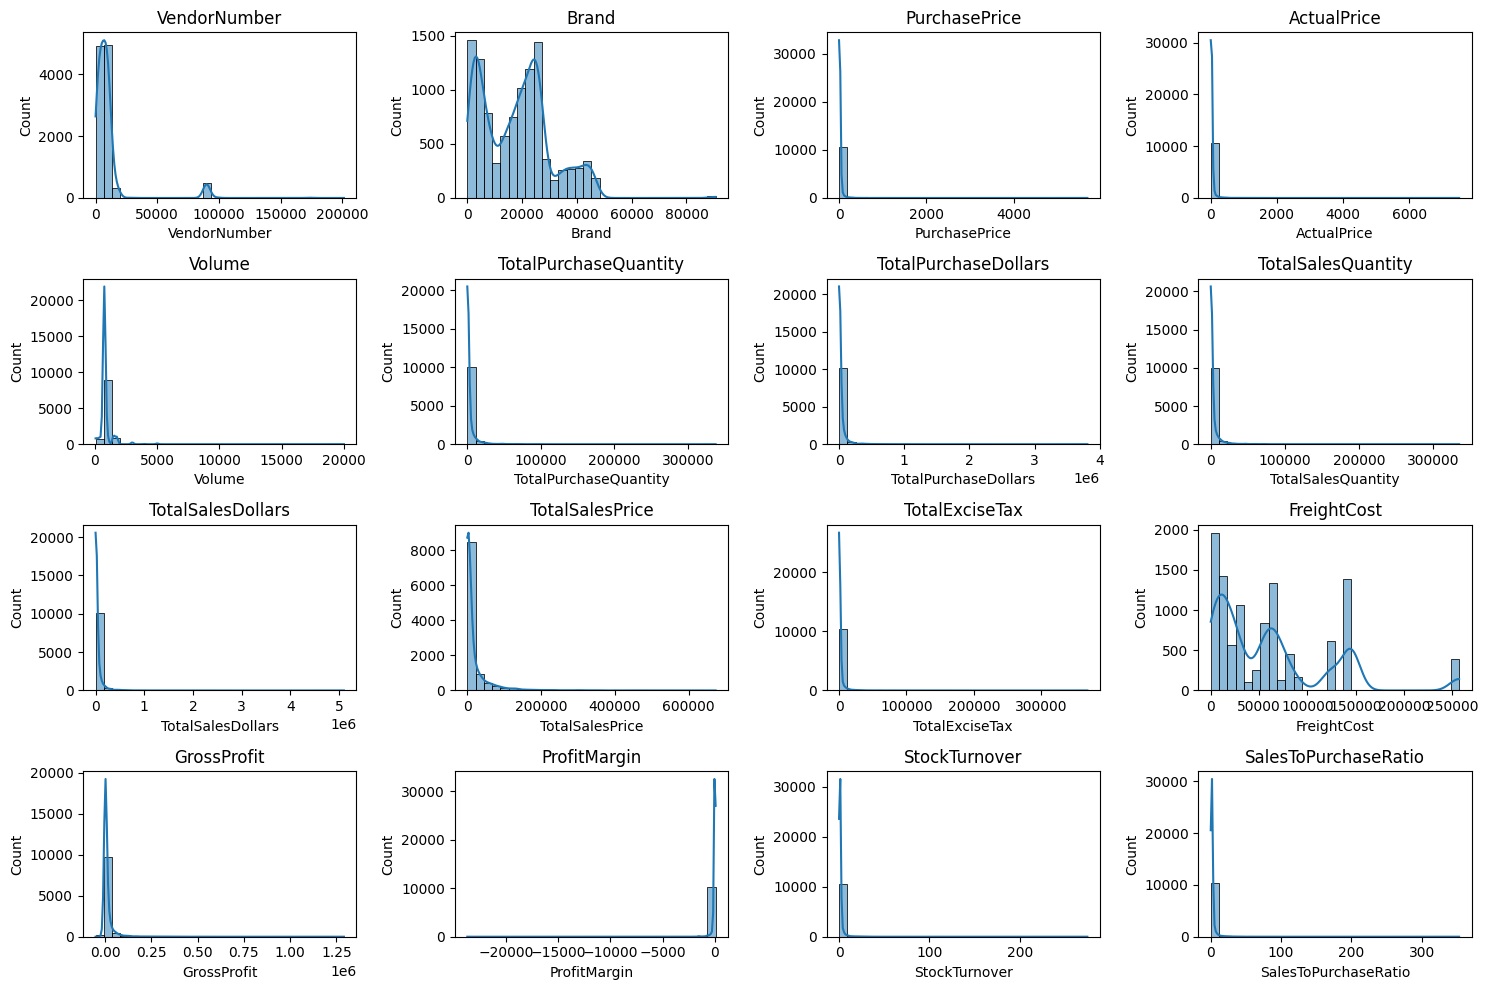

In [98]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # Adjust grid layout if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


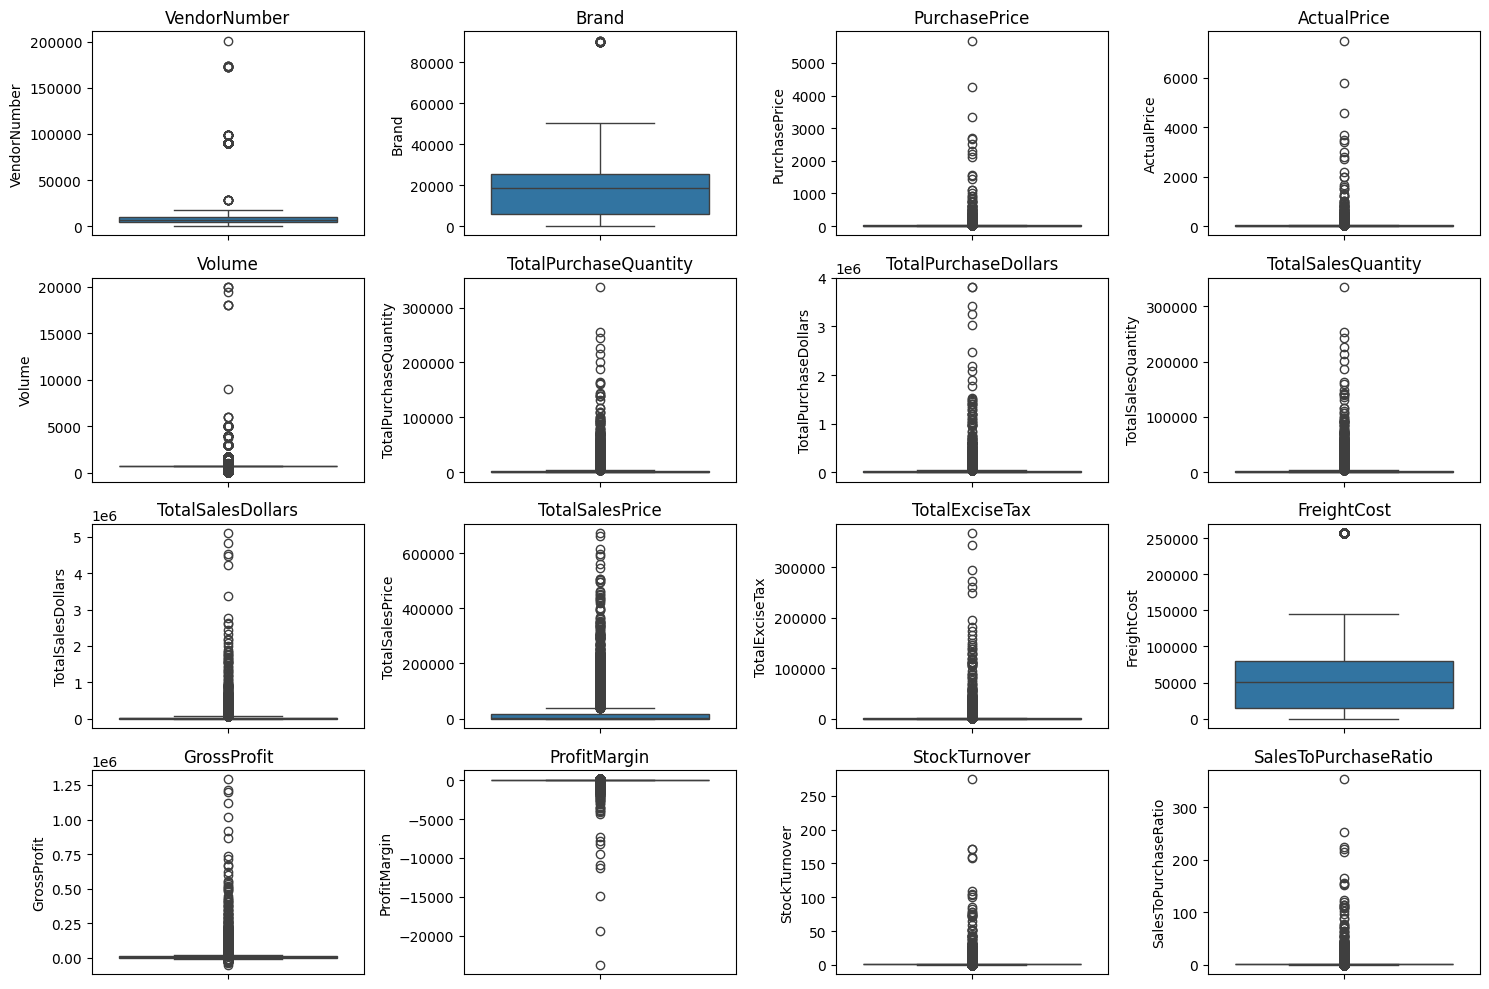

In [99]:
# Outlier detection with boxplots for numerical columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # Adjust grid layout if needed
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


## Summary Statistics – Key Insights

### Negative & Zero Values
- **Gross Profit**: The minimum value is **-52,002.78**, indicating losses. Some products or transactions may be sold at a loss due to high costs or heavy discounts below the purchase price.
- **Profit Margin**: The minimum value is **-∞**, which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity & Sales Dollars**: Minimum values are **0**, meaning some products were purchased but never sold. These may represent slow-moving or obsolete inventory.

---

### Outliers Indicated by High Standard Deviations
- **Purchase & Actual Prices**: Maximum values (**5,681.81** and **7,499.99**) are significantly higher than the means (**24.39** and **35.64**), indicating the presence of premium or outlier products.
- **Freight Cost**: Large variation (from **0.09** to **257,032.07**) suggests potential logistics inefficiencies, bulk shipments, or unusually high transport costs for certain vendors.
- **Stock Turnover**: Ranges from **0 to 274.5**, implying that some products sell extremely fast while others remain in inventory indefinitely. A value greater than **1** indicates that sales volume exceeds purchase volume, possibly due to sales being fulfilled from older stock.


In [100]:
# Filter data by removing inconsistencies
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
  AND ProfitMargin > 0
  AND TotalSalesQuantity > 0
""", engine)


In [101]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18,665.82,295.92,2.00,27.08,474.94,71.33,2.25,3.49
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47,704.53,494.67,37.01,367.52,258.37,36.67,1.21,1.58
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12,359.88,59.98,9.44,62.39,80.88,22.47,1.00,1.29
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307,15346.93,12947.41,242.15,62.39,3919.73,25.54,0.96,1.34
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84,1511.16,287.84,9.43,6.19,577.08,38.19,0.88,1.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,375.0,138,2028.60,125,2498.75,1819.09,49.00,178.34,470.15,18.82,0.91,1.23
8560,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,750.0,267,5732.49,222,6435.78,5363.15,175.13,178.34,703.29,10.93,0.83,1.12
8561,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750.0,554,11955.32,452,12877.48,8205.12,356.14,178.34,922.16,7.16,0.82,1.08
8562,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750.0,1232,23863.84,982,24540.18,14469.21,773.87,202.50,676.34,2.76,0.80,1.03


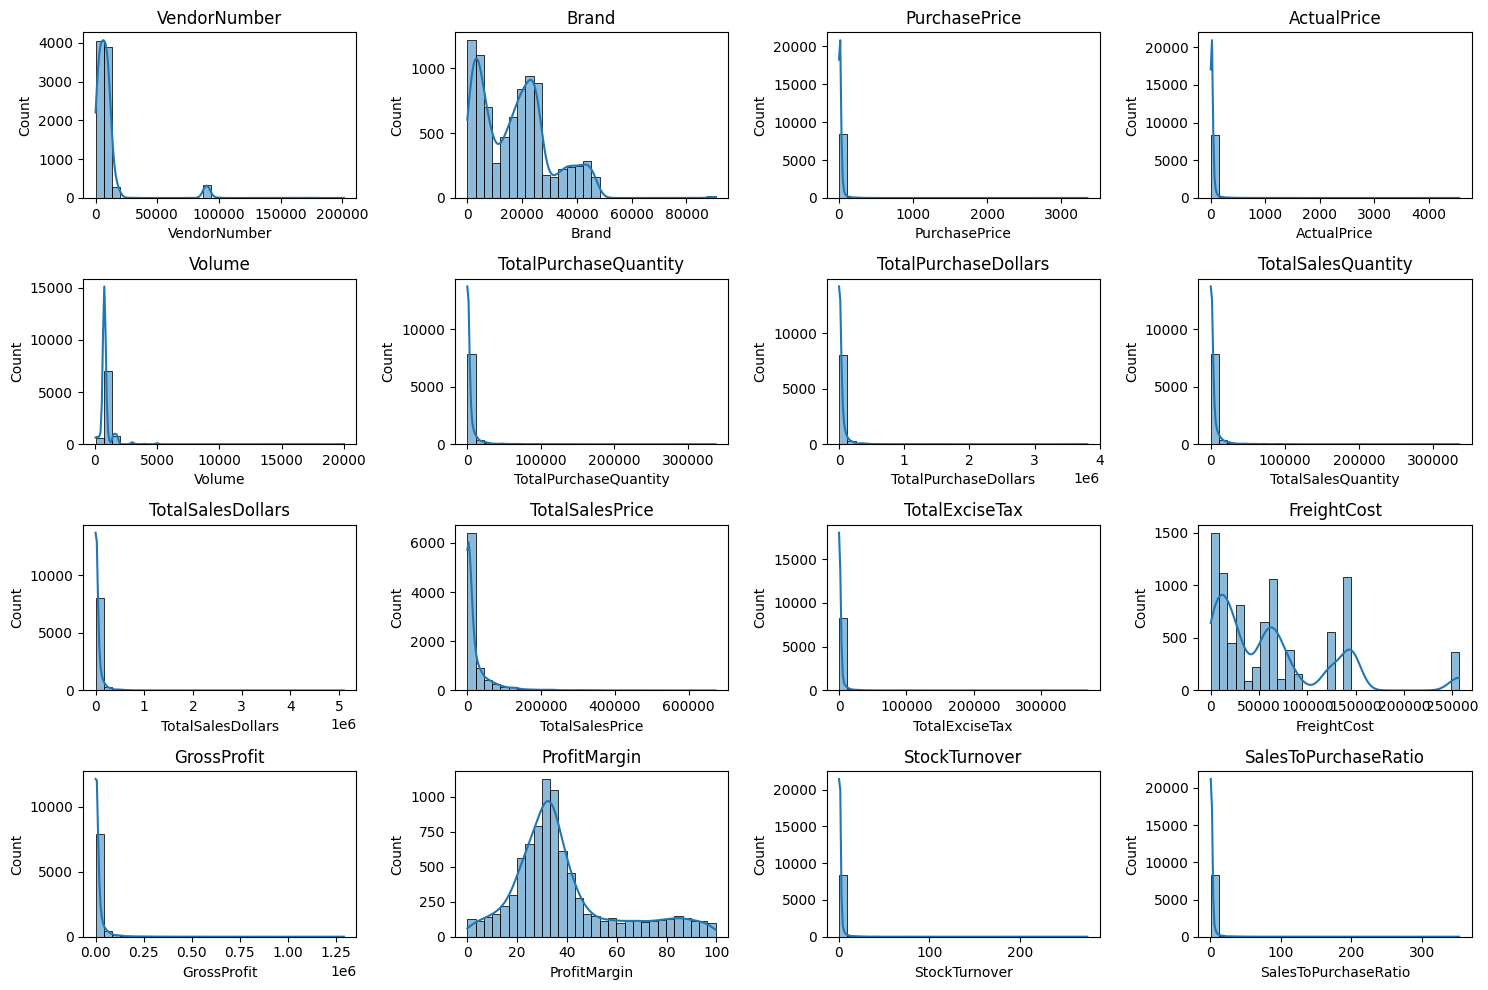

In [102]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # Adjust grid layout if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

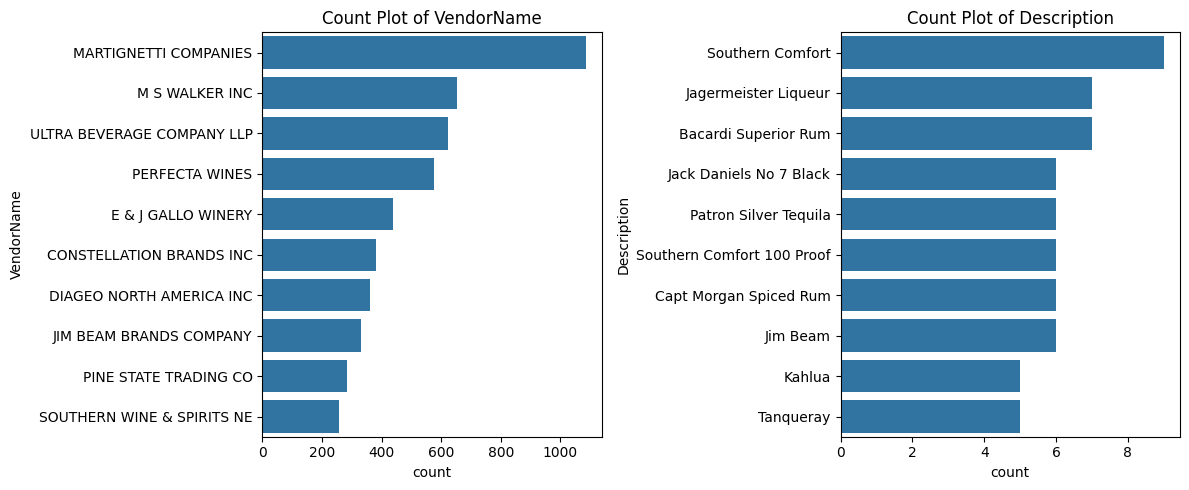

In [103]:
# Count plots for categorical columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]   # Top 10 categories
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()


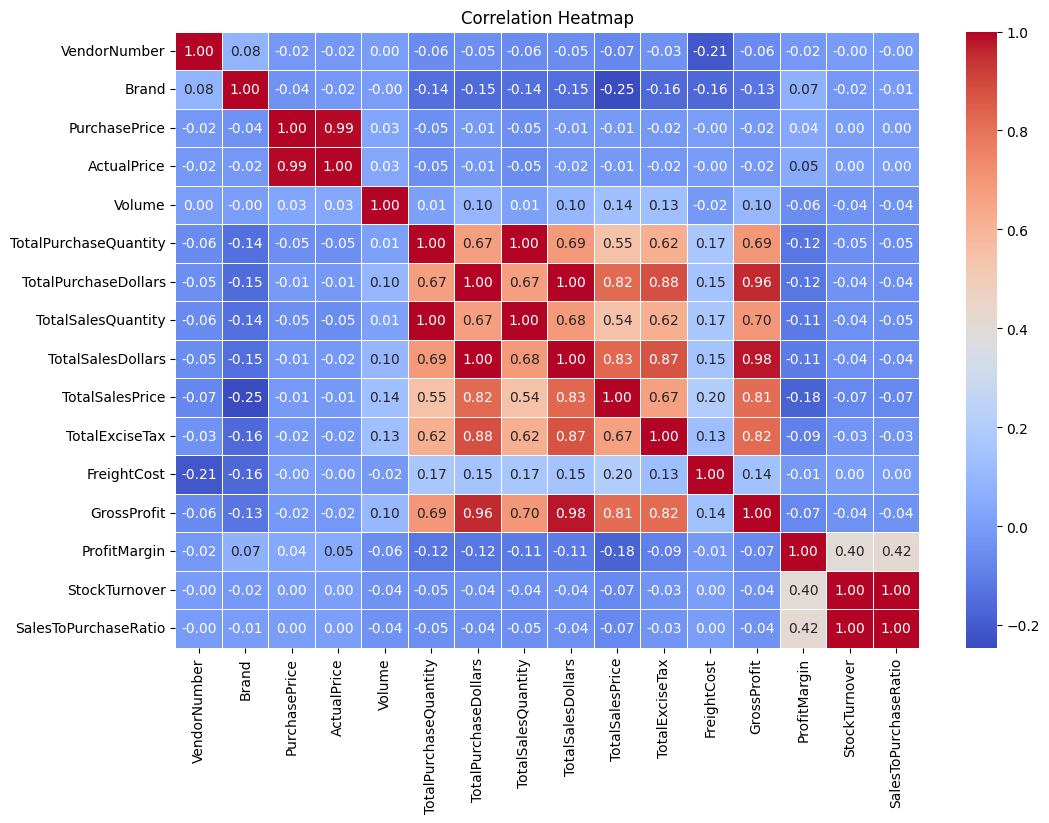

In [104]:
# Correlation heatmap for numerical columns
plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


## Correlation Insights

- **Purchase Price** shows weak correlations with **Total Sales Dollars** (-0.012) and **Gross Profit** (-0.016), indicating that price variations do not significantly impact overall revenue or profit.

- There is a **strong positive correlation** between **Total Purchase Quantity** and **Total Sales Quantity** (0.999), confirming efficient inventory movement from purchasing to sales.

- A **negative correlation** between **Profit Margin** and **Total Sales Price** (-0.179) suggests that as selling prices increase, margins tend to decrease—possibly due to competitive pricing pressures or higher associated costs.

- **Stock Turnover** has weak negative correlations with both **Gross Profit** (-0.038) and **Profit Margin** (-0.055), indicating that faster turnover does not necessarily translate into higher profitability.


## Data Analysis

**Objective:** Identify brands that require promotional strategies or pricing adjustments—specifically those that exhibit **lower sales performance** but maintain **higher profit margins**.


In [107]:
brand_performance = (
    df.groupby("Description")
      .agg({
          "TotalSalesDollars": "sum",
          "ProfitMargin": "mean"
      })
      .reset_index()
)


In [108]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.06
1,.nparalleled Svgn Blanc,1094.63,29.98
2,10 Span Cab Svgn CC,2703.89,20.94
3,10 Span Chard CC,3325.56,27.81
4,10 Span Pnt Gris Monterey Cy,2082.22,32.23
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.53
7703,Zuccardi Q Malbec,1639.18,23.98
7704,Zum Rsl,10857.34,32.68
7705,Zwack Liqueur,227.88,16.65


In [109]:
low_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_margin_threshold = brand_performance["ProfitMargin"].quantile(0.85)


In [110]:
low_sales_threshold

np.float64(560.299)

In [111]:
high_margin_threshold

np.float64(64.96799999999995)

In [112]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance["TotalSalesDollars"] <= low_sales_threshold) &
    (brand_performance["ProfitMargin"] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values(by="TotalSalesDollars"))


Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6237,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6245,Sbragia Home Ranch Merlot,549.75,66.44


In [113]:
# Filter for better visualization by limiting total sales
brand_performance = brand_performance[
    brand_performance["TotalSalesDollars"] < 10000
]


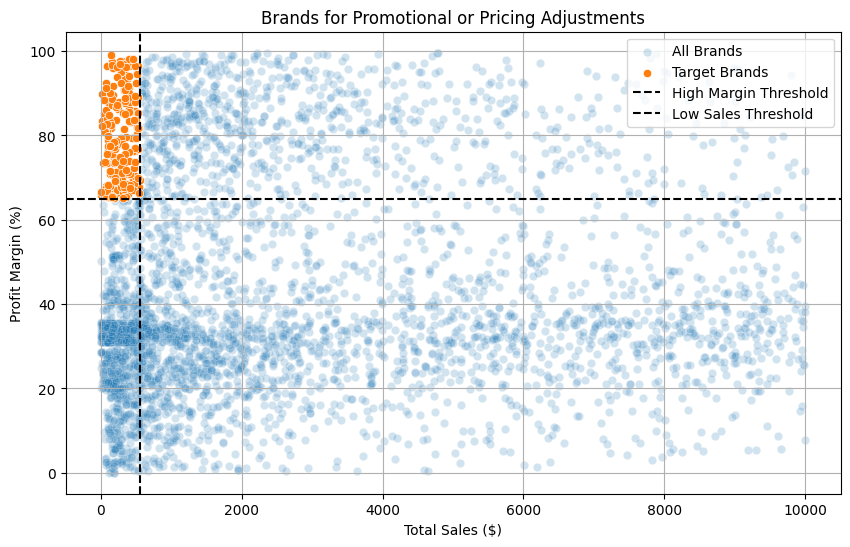

In [114]:
# Scatter plot: Sales vs Profit Margin
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    label="All Brands",
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x="TotalSalesDollars",
    y="ProfitMargin",
    label="Target Brands"
)

# Threshold reference lines
plt.axhline(
    y=high_margin_threshold,
    linestyle="--",
    color="black",
    label="High Margin Threshold"
)

plt.axvline(
    x=low_sales_threshold,
    linestyle="--",
    color="black",
    label="Low Sales Threshold"
)

# Labels and formatting
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


## Which Vendors and Brands Demonstrate the Highest Sales Performance?


In [116]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)


In [115]:
# Top vendors and brands by total sales
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

top_brands = (
    df.groupby("Description")["TotalSalesDollars"]
      .sum()
      .nlargest(10)
)

top_vendors, top_brands


(VendorName
 DIAGEO NORTH AMERICA INC      67990099.42
 MARTIGNETTI COMPANIES         39330359.36
 PERNOD RICARD USA             32063196.19
 JIM BEAM BRANDS COMPANY       31423020.46
 BACARDI USA INC               24854817.14
 CONSTELLATION BRANDS INC      24218745.65
 E & J GALLO WINERY            18399899.46
 BROWN-FORMAN CORP             18247230.65
 ULTRA BEVERAGE COMPANY LLP    16502544.31
 M S WALKER INC                14706458.51
 Name: TotalSalesDollars, dtype: float64,
 Description
 Jack Daniels No 7 Black    7964746.76
 Tito's Handmade Vodka      7399657.58
 Grey Goose Vodka           7209608.06
 Capt Morgan Spiced Rum     6356320.62
 Absolut 80 Proof           6244752.03
 Jameson Irish Whiskey      5715759.69
 Ketel One Vodka            5070083.56
 Baileys Irish Cream        4150122.07
 Kahlua                     3604858.66
 Tanqueray                  3456697.90
 Name: TotalSalesDollars, dtype: float64)

In [118]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

In [119]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

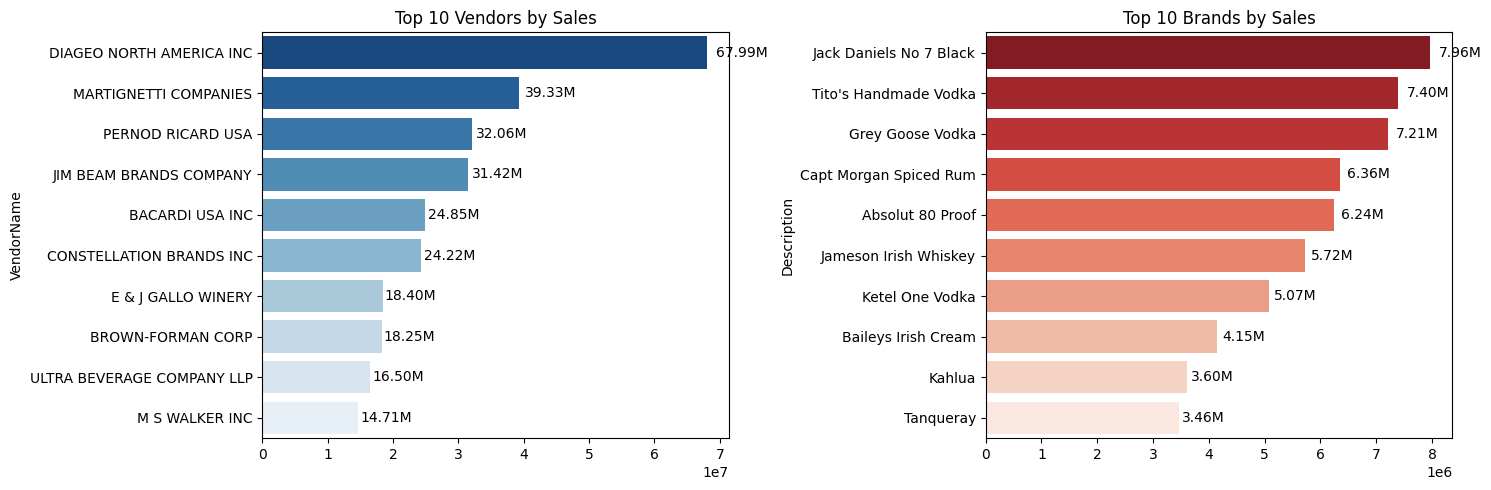

In [120]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.show()


## Which vendors contribute the most to total purchase dollars

In [125]:

vendor_performance = (
    df.groupby("VendorName")
      .agg({
          "TotalPurchaseDollars": "sum",
          "GrossProfit": "sum",
          "TotalSalesDollars": "sum"
      })
      .reset_index()
)



In [126]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [136]:
vendor_performance["PurchaseContribution%"] = (
    vendor_performance["TotalPurchaseDollars"]
    / vendor_performance["TotalPurchaseDollars"].sum()*100
)


In [137]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [138]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [139]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors["TotalSalesDollars"] = top_vendors["TotalSalesDollars"].apply(format_dollars)
top_vendors["TotalPurchaseDollars"] = top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"] = top_vendors["GrossProfit"].apply(format_dollars)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [140]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [144]:
top_vendors["CumulativeContribution%"] = (
    top_vendors["PurchaseContribution%"].cumsum()
)


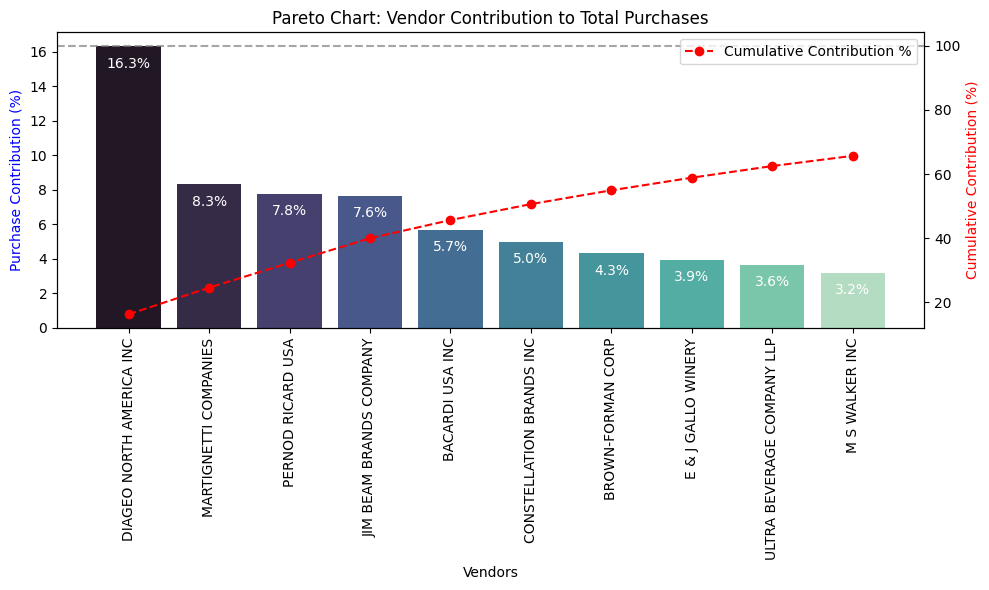

In [145]:
# Pareto Chart: Vendor Contribution to Total Purchases
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors["VendorName"],
    y=top_vendors["PurchaseContribution%"],
    palette="mako",
    ax=ax1
)

# Add value labels on bars
for i, value in enumerate(top_vendors["PurchaseContribution%"]):
    ax1.text(
        i,
        value - 1,
        f"{value:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        color="white"
    )

# Line plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(
    top_vendors["VendorName"],
    top_vendors["CumulativeContribution%"],
    color="red",
    marker="o",
    linestyle="--",
    label="Cumulative Contribution %"
)

# Axis labels and title
ax1.set_xlabel("Vendors")
ax1.set_ylabel("Purchase Contribution (%)", color="blue")
ax2.set_ylabel("Cumulative Contribution (%)", color="red")
ax1.set_xticklabels(top_vendors["VendorName"], rotation=90)
ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

# Reference line at 100%
ax2.axhline(y=100, color="gray", linestyle="--", alpha=0.7)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


## How much of total procurement is dependent on top vendors ?

In [147]:
print(
    f"Total Purchase Contribution of Top 10 Vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum(), 2)}%"
)


Total Purchase Contribution of Top 10 Vendors is 65.69%


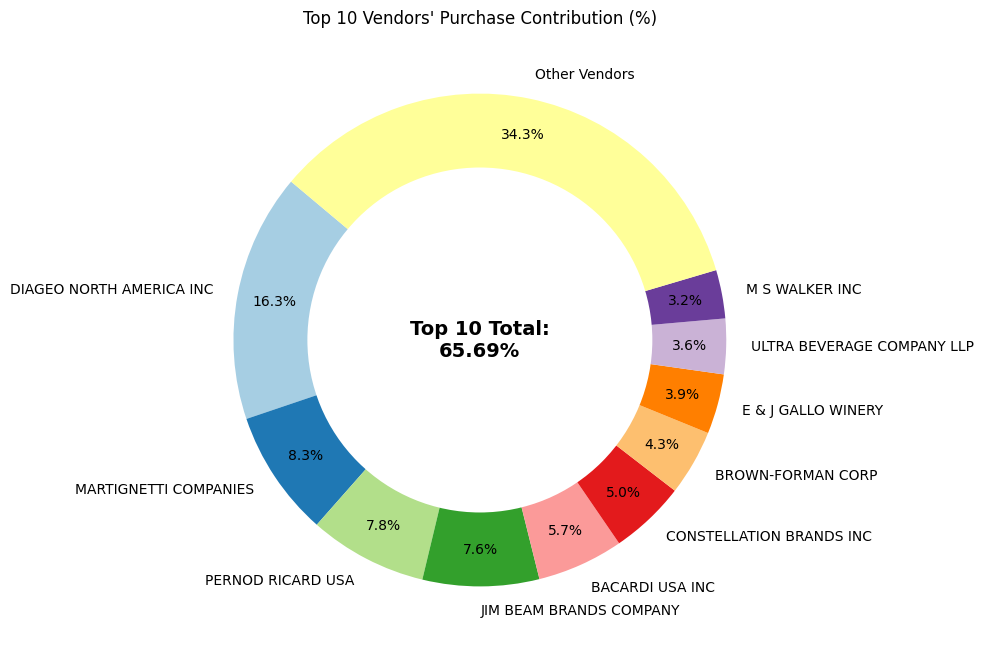

In [148]:
# Prepare data for donut chart
vendors = list(top_vendors["VendorName"].values)
purchase_contributions = list(top_vendors["PurchaseContribution%"].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig.gca().add_artist(centre_circle)

# Add total contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="center"
)

plt.title("Top 10 Vendors' Purchase Contribution (%)")
plt.show()


## Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings ?

In [149]:
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

df


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18,665.82,295.92,2.00,27.08,474.94,71.33,2.25,3.49,23.86
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47,704.53,494.67,37.01,367.52,258.37,36.67,1.21,1.58,11.44
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12,359.88,59.98,9.44,62.39,80.88,22.47,1.00,1.29,23.25
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307,15346.93,12947.41,242.15,62.39,3919.73,25.54,0.96,1.34,35.71
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84,1511.16,287.84,9.43,6.19,577.08,38.19,0.88,1.62,9.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,375.0,138,2028.60,125,2498.75,1819.09,49.00,178.34,470.15,18.82,0.91,1.23,14.70
8560,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,750.0,267,5732.49,222,6435.78,5363.15,175.13,178.34,703.29,10.93,0.83,1.12,21.47
8561,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750.0,554,11955.32,452,12877.48,8205.12,356.14,178.34,922.16,7.16,0.82,1.08,21.58
8562,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750.0,1232,23863.84,982,24540.18,14469.21,773.87,202.50,676.34,2.76,0.80,1.03,19.37


In [150]:
# Categorize order sizes into quantile-based groups
df["OrderSize"] = pd.qcut(
    df["TotalPurchaseQuantity"],
    q=3,
    labels=["Small", "Medium", "Large"]
)




In [151]:
df[["OrderSize", "TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Small,8
1,Small,39
2,Small,12
3,Medium,320
4,Medium,96
...,...,...
8559,Medium,138
8560,Medium,267
8561,Medium,554
8562,Medium,1232


In [152]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


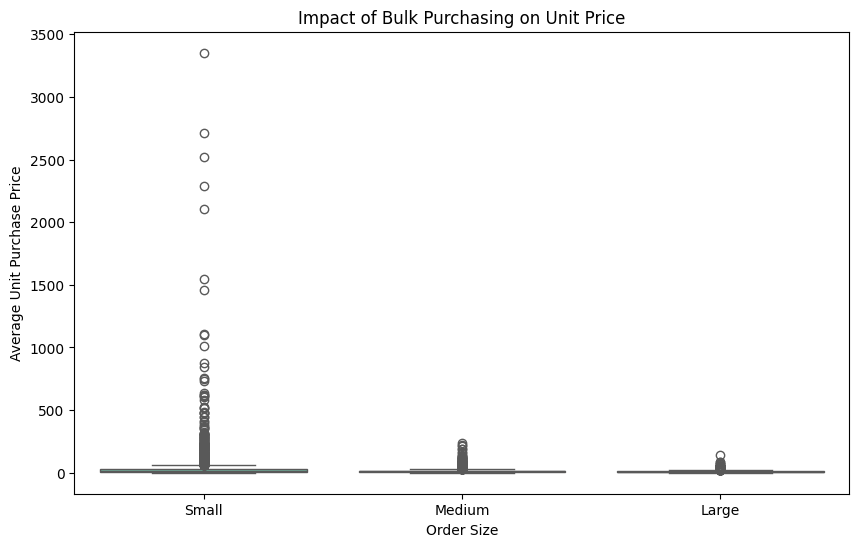

In [153]:
# Boxplot: Impact of order size on unit purchase price
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


### Key Insights: Impact of Order Size on Unit Price

- Vendors purchasing in **bulk (Large Order Size)** receive the **lowest unit price** (approximately **$10.78 per unit**), which can result in **higher margins** if inventory is managed efficiently.

- The price difference between **Small** and **Large** orders is substantial (around **72% reduction in unit cost**), highlighting the financial advantage of bulk purchasing.

- This indicates that **bulk pricing strategies** effectively incentivize vendors to purchase larger quantities, leading to **higher overall sales volume** despite lower revenue per unit.


## Which vendors have low inventory turnover, indicating excess stock and slow moving products ?

In [156]:
low_turnover_vendors = (
    df[df["StockTurnover"] < 1]
      .groupby("VendorName")["StockTurnover"]
      .mean()
      .reset_index()
)


In [160]:
low_turnover_vendors.sort_values('StockTurnover', ascending = True).head(10)

,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.620000
36,HIGHLAND WINE MERCHANTS LLC,0.710000
60,PARK STREET IMPORTS LLC,0.750000
19,Circa Wines,0.755385
41,KLIN SPIRITS LLC,0.760000
26,Dunn Wine Brokers,0.767500
15,CENTEUR IMPORTS LLC,0.772500
78,SMOKY QUARTZ DISTILLERY LLC,0.780000
90,TAMWORTH DISTILLING,0.800000
91,THE IMPORTED GRAPE LLC,0.808182


## How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it ?

In [161]:
# Calculate unsold inventory value
df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"])
    * df["PurchasePrice"]
)

# Print total unsold capital
total_unsold_capital = df["UnsoldInventoryValue"].sum()
print(f"Total Unsold Capital: {format_dollars(total_unsold_capital)}")


Total Unsold Capital: 2.71M


In [162]:
# Aggregate capital locked per vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
      .sum()
      .reset_index()
)

# Sort vendors by highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

# Format values for display
inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
)

inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


## What is the 95% confidence intervals for profit margins of top - performing and low - performing vendors ?

In [163]:
# Define top and low sales thresholds using quartiles
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)




In [164]:
# Extract profit margins for top and low performing vendors
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [165]:
top_vendors

5       17.00
8       30.56
13      30.83
14      27.13
17      24.33
        ...  
8536    25.17
8537    22.89
8538    22.65
8552    27.10
8554    28.06
Name: ProfitMargin, Length: 2141, dtype: float64

In [166]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


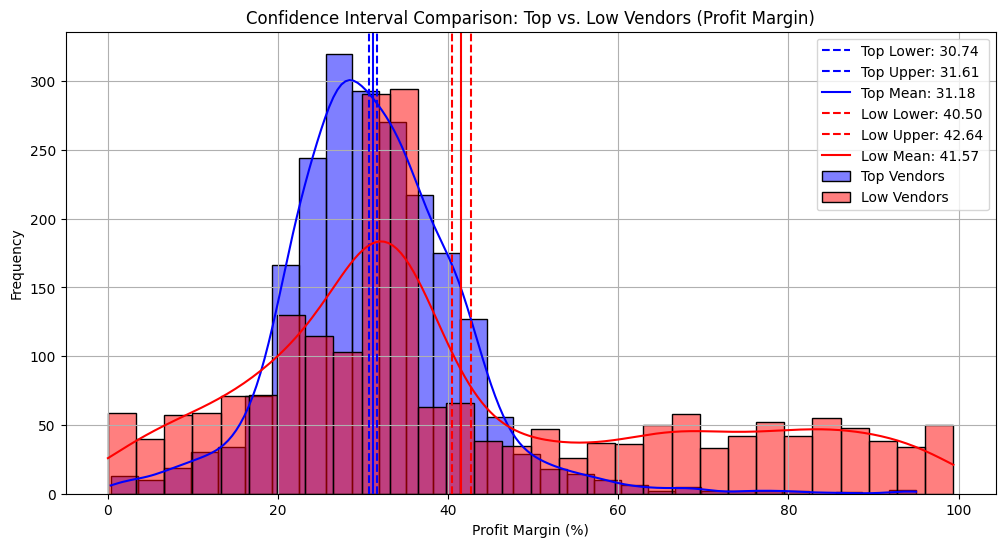

In [167]:
# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Print results
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

# Create plot
plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean,  color="blue", linestyle="-",  label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean,  color="red", linestyle="-",  label=f"Low Mean: {low_mean:.2f}")

# Finalize plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


### Confidence Interval Insights

- The **confidence interval for low-performing vendors** (**40.48%–42.62%**) is significantly higher than that of **top-performing vendors** (**30.74%–31.61%**).

- This indicates that vendors with **lower sales volumes** tend to maintain **higher profit margins**, potentially due to **premium pricing**, niche positioning, or lower operational costs.

- **For high-performing vendors:** To further improve profitability, they could explore **selective price adjustments**, **cost optimization**, or **bundling strategies**.

- **For low-performing vendors:** Despite higher margins, their limited sales volume suggests a need for **better marketing**, **more competitive pricing**, or **improved distribution strategies**.


## Is There a Significant Difference in Profit Margins Between Top-Performing and Low-Performing Vendors?

### Hypothesis

- **H₀ (Null Hypothesis):** There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

- **H₁ (Alternative Hypothesis):** The mean profit margins of top-performing and low-performing vendors are significantly different.


In [169]:
# Define thresholds based on sales quantiles
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Extract profit margins for top and low-performing vendors
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform two-sample t-test (Welch's t-test)
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6693, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
